In this notebook, we aim to produce scatterplots for analyzing the correlation between two datsets.

In [3]:
from geostat_isoscapes_tools import geostat_utils,utils, plot_utils, sisal_utils
import seaborn as sns
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

sns.set_theme(
    style="ticks",
    context="talk",
    font_scale=0.9
)

## Correlation of SISAL and iTrace data points

In [3]:
# import sisal data 
sisal_df = geostat_utils.get_sisal_data_for_kriging(res=1,regions=None) # res=1 year
# import itrace data
sim_kyr = 12
itrace_df = geostat_utils.get_preprocessed_itrace_data(res=12,sim_kyr=sim_kyr,sim_num='05',sim_suffix='800001-899912',format='df') # res=12months=1yr
# keep only data within this itrace time range
sisal_df = sisal_df[sisal_df['age'].between((sim_kyr-1)*1000, sim_kyr*1000)]

loading sisal data
-> loading SISAL database
   cleaning samples
loading and cleaning done.
-> converting speleothem data
   linear interpolation failed for 121612 samples, trying to fill missing T with nearest neighbour method
   after linear interpolation and nearest neighbour backup, still no temperature for 64562 samples.
   temperature retrieval finished, starting conversion
conversion done.
sisal dataframe is ready
loading itrace files
This dataset contains  12000  time steps.
   bins of width=12 months (1 years)
   converting xr to DataFrame (~2 minutes)
done


In [4]:
# take only the points that share same loc (radius around sisal = 50km) and time (yearly resolution), put them by pairs in a new dataframe
# 1. mask iTrace data to keep only points around sisal locs 
rad = 100
itrace_df_masked,_ = utils.mask_union_of_circles_around_pts(itrace_df,sisal_df[['lat','lon']],radius_km=rad)
# 2. retrieve the age in yr BP instead of the default time unit of itrace
itrace_df_masked['age']=utils.get_yrBP_from_itrace_time(itrace_df_masked['time'],start_year=sim_kyr*1000)

In [5]:
# 3. For each sisal point find the closest itrace point in space and time (same year and less than 50 km away), and store them as a pair in a new dataframe
paired_data=[]
for idx, sisal_row in sisal_df.iterrows():
    sisal_loc = (sisal_row['lat'],sisal_row['lon'])
    sisal_site_name = sisal_row['site_name']
    sisal_age = sisal_row['age']
    itrace_candidates = itrace_df_masked[itrace_df_masked['age']==sisal_age].copy()
    if len(itrace_candidates)==0:
        continue
    # find the closest itrace canditate
    itrace_candidates['dist_km'] = itrace_candidates.apply(lambda row : utils.haversine(sisal_loc,(row.lat,row.lon)), axis=1)
    closest_itrace = itrace_candidates.loc[itrace_candidates['dist_km'].idxmin()]
    if closest_itrace['dist_km']>rad:
        continue
    paired_data.append({'age':sisal_age,
                        'site':sisal_site_name,
                        'sisal_d18Op':sisal_row['d18Op_VSMOW_exactconv'],
                        'sisal_d18Oc': sisal_row['d18O_measurement'],
                        'itrace_d18Op':closest_itrace['d18Op'],
                        'sisal_lat':sisal_row['lat'],
                        'sisal_lon':sisal_row['lon'],
                        'itrace_lat':closest_itrace['lat'],
                        'itrace_lon':closest_itrace['lon'],
                        'dist_km':closest_itrace['dist_km']})
paired_df = pd.DataFrame(paired_data)


In [6]:
paired_df = sisal_utils.retrieve_continent_from_lat_lon(paired_df,lat_col='sisal_lat',lon_col='sisal_lon')
paired_df['color']=''
colors_continents = {'Asia': "#7d0303",
                     'North America': "#03838f",
                     'South America':  "#100a78",
                     'Middle East': "#244a1f",
                     'Europe': "#72b45e",
                     'Oceania': "#4A1178",
                     'Indonesia': "#f6c207",
                     'Africa' : "#a93b95"
                     }
for continent,color in colors_continents.items():
    paired_df.loc[paired_df['continent']==continent,'color']=color

In [7]:
paired_df_asia = paired_df[paired_df['continent']=='Asia']
print(paired_df_asia.site.unique())

['Kesang cave' 'Furong cave' 'Dongge cave' 'Kinderlinskaya cave'
 'Sanbao cave' 'Jiuxian cave' 'Yamen cave' 'Timta cave' 'Mawmluh cave'
 'Lianhua cave, Hunan' 'Haozhu cave' 'Wanxiang cave' 'Shennong cave'
 'Wuya cave' 'Yangzi cave']


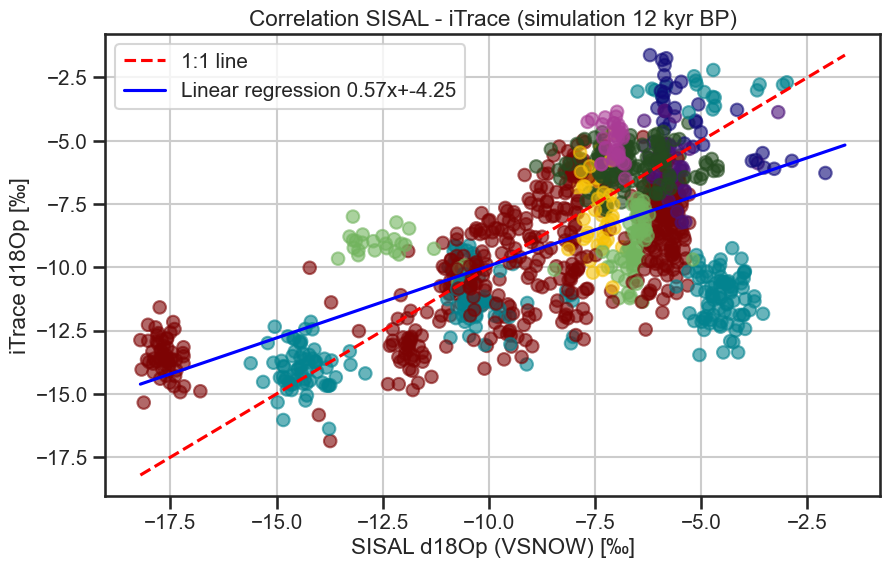

In [10]:
# df = paired_df_asia[paired_df_asia['site']!='Kinderlinskaya cave'] # kinderlinskaya = cluster of overestimation itrace/ underestimation sisal
df = paired_df
x = 'sisal_d18Op'
y = 'itrace_d18Op'

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df[x],df[y],c=df['color'].values,alpha=0.6)
# 1:1 line
min_val = min(df[x].min(), df[y].min())
max_val = max(df[x].max(), df[y].max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 line')
# fit
slope, intercept = np.polyfit(df[x], df[y], 1)
x_vals = np.array([min_val, max_val])
y_vals = intercept + slope * x_vals
ax.plot(x_vals, y_vals, color='blue', linestyle='-', label=f'Linear regression {slope :.2f}x+{intercept :.2f}')
ax.legend()
ax.set_xlabel('SISAL d18Op (VSNOW) [‰]')
ax.set_ylabel('iTrace d18Op [‰]')
ax.set_title(f'Correlation SISAL - iTrace (simulation {sim_kyr} kyr BP)')
plt.grid()
plt.show()

In [11]:
paired_df['ratio']=np.log(paired_df['itrace_d18Op']/paired_df['sisal_d18Op'])  # logbias : ln(s/i) si s>i -> positive (overestimation), si s<i -> negative : underestimation
plot_utils.plot_global_map(paired_df,title='ratio ln(itrace_d18Op/sisal_d18Op)',
                           quantity_col='ratio',
                           quantity='d18Op_itrace/d18Op_sisal',
                           unit='',
                           lon_col='sisal_lon',
                           lat_col='sisal_lat',
                           colorscale='RdBu',
                           landcolor="#3a5540",
                           symbol='circle')

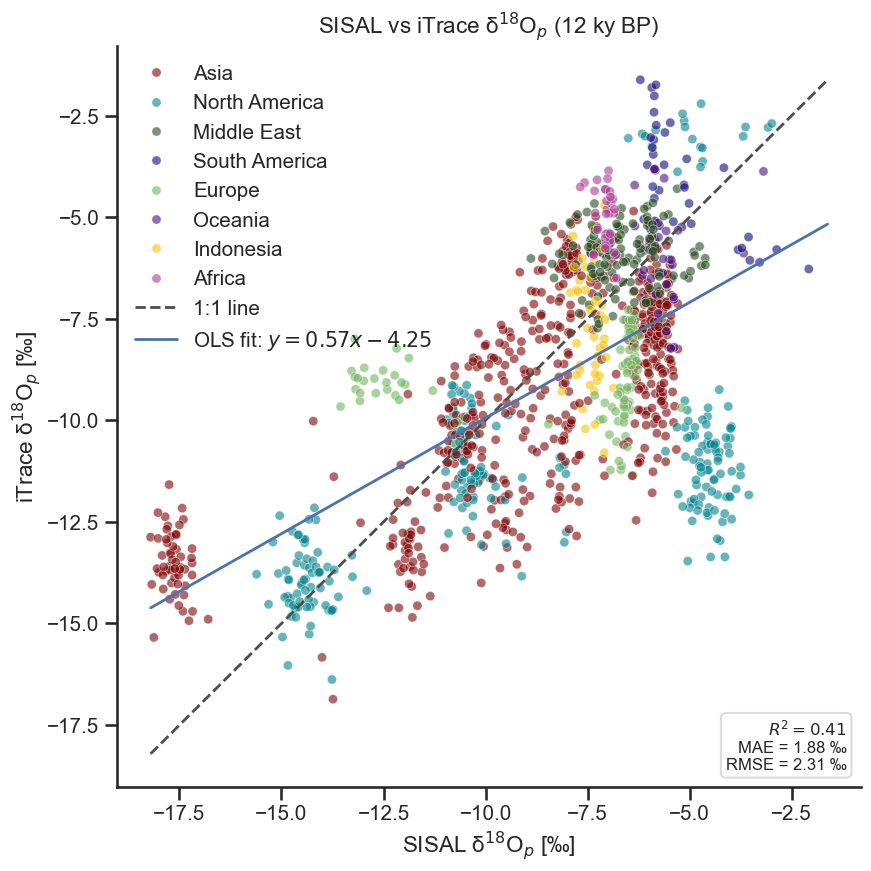

In [ ]:
df = paired_df
x = 'sisal_d18Op'
y = 'itrace_d18Op'

fig, ax = plt.subplots(figsize=(9,9))

sns.scatterplot(
    data=df,
    x=x,
    y=y,
    s=45,
    alpha=0.6,
    hue='continent',
    palette=colors_continents,
    edgecolor="white",
    linewidth=0.5,
    ax=ax)

# 1:1 line
min_val = min(df[x].min(),df[y].min())
max_val = max(df[x].max(),df[y].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="0.3",
    label="1:1 line")

# Linear fit
slope, intercept = np.polyfit( df[x],df[y],1)

x_vals = np.linspace(min_val, max_val, 200)
y_vals = intercept + slope * x_vals

ax.plot(x_vals,y_vals,linewidth=2,label=fr'OLS fit: $y={slope:.2f}x {intercept:+.2f}$')

# Metrics
y_fit = intercept + slope * df[x]
y_true = df[y].values

r2 = utils.r2(y_true, y_fit)
rse = utils.RSE(y_true, y_fit, 2)
rmse = utils.RMSE(y_true, y_fit)
mae = utils.MAE(y_true,y_fit)

ax.text(
    0.98,
    0.02,
    fr'$R^2 = {r2:.2f}$' '\n'
    # fr'RSE = {rse:.2f} ‰' '\n'
    fr'MAE = {mae:.2f} ‰' '\n'
    fr'RMSE = {rmse:.2f} ‰',
    transform=ax.transAxes,
    va='bottom',
    ha='right',
    fontsize=12,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="0.85",
        alpha=0.9))

# Labels
ax.set_xlabel('SISAL δ$^{18}$O$_p$ [‰]')
ax.set_ylabel('iTrace δ$^{18}$O$_p$ [‰]')
ax.set_title('SISAL versus iTrace δ$^{18}$O$_p$ (12 ky BP)', pad=10)

# Final styling
sns.despine(ax=ax)
ax.legend(frameon=False)
# ax.set_aspect('equal', adjustable='box')

fig.tight_layout()
# plt.savefig('../output/correlation_scatterplot_itrace_sisal.png',dpi=300)
plt.show()


## Correlation between RCWIP and SISAL data

In [4]:
import rasterio
from rasterio.transform import xy
from tqdm import tqdm

sisal_df = geostat_utils.get_sisal_data_for_kriging(res=None, regions=None, conversion=None)
sisal_df=sisal_df[sisal_df['age'].between(-66,-10)] # rcwip covers 1950-2016 = "-10"yrBP to "-66"yrBP
sisal_df = sisal_df[['lat','lon','d18O_measurement','site_id']].groupby('site_id').mean()
pairs_df_list = []
for lon in [150,120,90,60,30,0,-30,-60,-90,-120,-150,-180]:
    if lon<0:
        lo = f'W{-lon}'
    else : 
        lo = f'E{lon}'
    for lat in [60,30,0,-30,-60]:
        if lat<0:
            la = f'S{-lat}'
        else : 
            la = f'N{lat}'
        
        print('=============',lo,la,'===============')
        print(f'searching lat between {lat},{lat+30} and lon between {lon},{lon+30}')
        sisal_subdf = sisal_df[sisal_df['lat'].between(lat,lat+30) & sisal_df['lon'].between(lon,lon+30)].copy()
        if len(sisal_subdf)==0:
            print('no sisal data in this area')
            continue
        try :
            with rasterio.open(f'../data/modern/RCWIP2_isoscape/O18_{lo}_{la}_13.tif') as f:
                rcwip_data = f.read(1)
                transform = f.transform
                crs = f.crs
                nodata= f.nodata
        except Exception as e :
            print(e)
            continue

        # compute coordinates 
        rows, cols = np.meshgrid(
            np.arange(rcwip_data.shape[0]),
            np.arange(rcwip_data.shape[1]),
            indexing="ij"
        )
        xs, ys = xy(transform, rows, cols, offset="center")
        xs = np.array(xs)
        ys = np.array(ys)

        # get valid pixels
        values = rcwip_data.ravel()
        mask = np.ones(values.shape, dtype=bool)
        mask &= np.abs(values)<10e3
        mask &= ~np.isnan(values)

        # convert to dataframe
        rcwip_df = pd.DataFrame({
            "lon": xs[mask],
            "lat": ys[mask],
            "value": values[mask]
        })
        
        paired_data=[]
        rad = 100
        for idx, sisal_row in tqdm(sisal_subdf.groupby('site_id')):
            sisal_loc = (sisal_row['lat'].values[0],sisal_row['lon'].values[0])
            # find the closest rcwip point. Easy since it has a regular grid
            rcwip_df['dlat']=np.abs(rcwip_df['lat']-sisal_loc[0])
            rcwip_df['dlon']=np.abs(rcwip_df['lon']-sisal_loc[1])
            min_lon = rcwip_df.loc[rcwip_df['dlon'].idxmin(),'lon']
            min_lat = rcwip_df.loc[rcwip_df['dlat'].idxmin(),'lat']
            closest_rcwip = rcwip_df[(rcwip_df['lon']==min_lon)&(rcwip_df['lat']==min_lat)]
            
            if len(closest_rcwip)==0: # in case the optimal grid point is not valid (removed earlier from rcwip data)
                print('missing data - computing distances...')
                eps=1.
                i=1
                while len(closest_rcwip)<1:
                    eps *= i
                    rcwip_subdf = rcwip_df[rcwip_df['lon'].between(sisal_loc[1]-eps,sisal_loc[1]+eps)
                                        & rcwip_df['lat'].between(sisal_loc[0]-eps,sisal_loc[0]+eps)].copy()
                    print(rcwip_subdf)
                    rcwip_subdf['dist_km'] = rcwip_subdf.apply(lambda row : utils.haversine(sisal_loc,(row.lat,row.lon)), axis=1)
                    candidate = rcwip_subdf.iloc[rcwip_subdf['dist_km'].idxmin()]
                    if candidate['dist_km']>rad:
                        print('found closest point at', closest_rcwip['dist_km'],'km -> too far away')
                        i += 1
                    closest_rcwip = candidate
                    print('found closest point at', closest_rcwip['dist_km'],'km')
            
            paired_data.append({'sisal_d18Oc':sisal_row['d18O_measurement'].values[0],
                                'rcwip_d18Op':closest_rcwip['value'].values[0],
                                'sisal_lat':sisal_row['lat'].values[0],
                                'sisal_lon':sisal_row['lon'].values[0],
                                'rcwip_lat':closest_rcwip['lat'].values[0],
                                'rcwip_lon':closest_rcwip['lon'].values[0],
                                })
        pairs_df_list.append(pd.DataFrame(paired_data))

pairs_df = pd.concat(pairs_df_list)

loading sisal data
-> loading SISAL database
   cleaning samples
loading and cleaning done.
sisal dataframe is ready
============= E150 N60 ===============
searching lat between 60,90 and lon between 150,180
no sisal data in this area
============= E150 N30 ===============
searching lat between 30,60 and lon between 150,180
no sisal data in this area
============= E150 N0 ===============
searching lat between 0,30 and lon between 150,180
no sisal data in this area
============= E150 S30 ===============
searching lat between -30,0 and lon between 150,180


100%|██████████| 2/2 [00:00<00:00, 85.98it/s]


============= E150 S60 ===============
searching lat between -60,-30 and lon between 150,180


100%|██████████| 3/3 [00:00<00:00, 181.78it/s]


============= E120 N60 ===============
searching lat between 60,90 and lon between 120,150
no sisal data in this area
============= E120 N30 ===============
searching lat between 30,60 and lon between 120,150


...

============= W90 S60 ===============
searching lat between -60,-30 and lon between -90,-60
no sisal data in this area
============= W120 N60 ===============
searching lat between 60,90 and lon between -120,-90
no sisal data in this area
============= W120 N30 ===============
searching lat between 30,60 and lon between -120,-90


100%|██████████| 5/5 [00:00<00:00,  6.69it/s]


============= W120 N0 ===============
searching lat between 0,30 and lon between -120,-90


100%|██████████| 1/1 [00:00<00:00, 43.42it/s]

============= W120 S30 ===============
searching lat between -30,0 and lon between -120,-90
no sisal data in this area
============= W120 S60 ===============
searching lat between -60,-30 and lon between -120,-90
no sisal data in this area
============= W150 N60 ===============
searching lat between 60,90 and lon between -150,-120
no sisal data in this area
============= W150 N30 ===============
searching lat between 30,60 and lon between -150,-120
no sisal data in this area
============= W150 N0 ===============
searching lat between 0,30 and lon between -150,-120
no sisal data in this area
============= W150 S30 ===============
searching lat between -30,0 and lon between -150,-120
no sisal data in this area
============= W150 S60 ===============
searching lat between -60,-30 and lon between -150,-120
no sisal data in this area
============= W180 N60 ===============
searching lat between 60,90 and lon between -180,-150
no sisal data in this area
============= W180 N30 ===============
s

In [20]:
len(pairs_df)

114

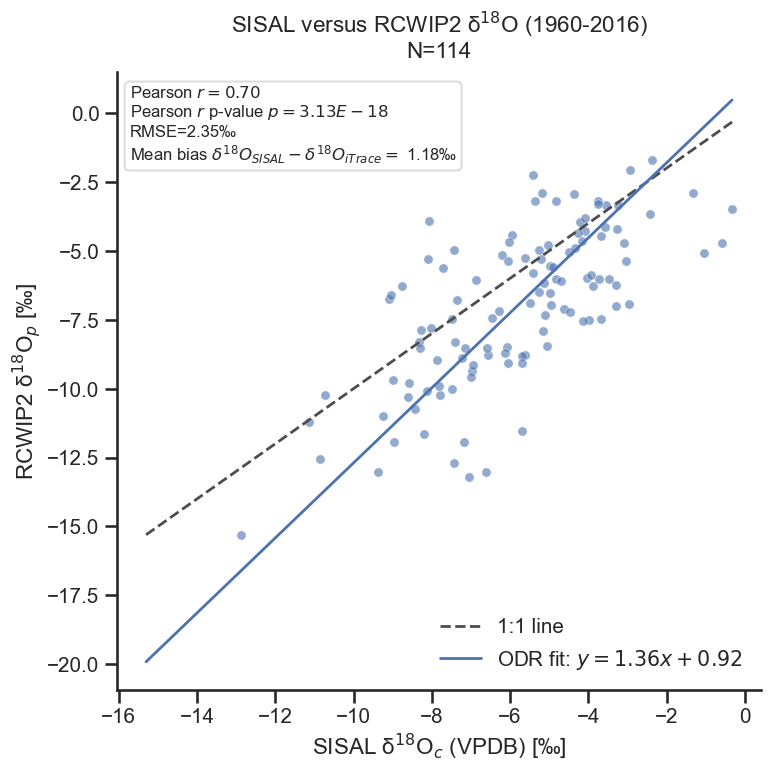

In [29]:
from scipy.stats import pearsonr
from scipy import odr

def linear_model(B, x):
    return B[0] * x + B[1]

fig, ax = plt.subplots(figsize=(8, 8))
x = 'sisal_d18Oc'
y = 'rcwip_d18Op'

#metrics
r, p_value = pearsonr(pairs_df[x], pairs_df[y])


sns.scatterplot(
    data=pairs_df,
    x=x,
    y=y,
    s=45,
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5,
    ax=ax)

# 1:1 line
min_val = min(pairs_df[x].min(),pairs_df[y].min())
max_val = max(pairs_df[x].max(),pairs_df[y].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="0.3",
    label="1:1 line")

# Linear fit # this is a wrong method since it assumes that x has no error!
# slope, intercept = np.polyfit(
#     pairs_df[x],
#     pairs_df[y],
#     1)
# y_vals = intercept + slope * x_vals
# ax.plot(
#     x_vals,
#     y_vals,
#     linewidth=2,
#     label=fr'OLS fit: $y={slope:.2f}x {intercept:+.2f}$')
model = odr.Model(linear_model)
data = odr.Data(pairs_df[x], pairs_df[y])
odr_fit = odr.ODR(data, model, beta0=[1, 0])
out = odr_fit.run()
slope, intercept = out.beta
x_vals = np.linspace(min_val, max_val, 200)
y_vals = intercept + slope * x_vals
ax.plot(
    x_vals,
    y_vals,
    linewidth=2,
    label=fr'ODR fit: $y={slope:.2f}x {intercept:+.2f}$')

# Metrics
rmse = utils.RMSE(pairs_df[x], pairs_df[y])
bias = np.mean(pairs_df[x]-pairs_df[y])

ax.text(
    0.02,
    0.98,

    fr'Pearson $r={r:.2f}$' '\n'
    fr'Pearson $r$ p-value $p={p_value :.2E}$' '\n'
    # fr'RSE = {rse:.2f} ‰' '\n'
    # fr'MAE = {mae : .2f} ‰' '\n'
    fr'RMSE={rmse:.2f}‰' '\n'
    r'Mean bias $\delta^{18}O_{SISAL}-\delta^{18}O_{iTrace}=$' f'{bias : .2f}‰'
    ,
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=12,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="0.85",
        alpha=0.9))

# Labels
ax.set_xlabel('SISAL δ$^{18}$O$_c$ (VPDB) [‰]')
ax.set_ylabel('RCWIP2 δ$^{18}$O$_p$ [‰]')
ax.set_title('SISAL versus RCWIP2 δ$^{18}$O (1960-2016)' '\n' 'N=114', pad=10)

# Final styling
sns.despine(ax=ax)
ax.legend(frameon=False)
# ax.set_aspect('equal', adjustable='box')

fig.tight_layout()
plt.savefig('../output/correlation_scatterplot_rcwip_sisal.png',dpi=300)
plt.show()


In [ ]:
pairs_df['ratio']=np.log(pairs_df['rcwip_d18Op']/pairs_df['sisal_d18Oc'])  # logbias : ln(s/i) si s>i -> positive (overestimation), si s<i -> negative : underestimation
plot_utils.plot_global_map(pairs_df,title='ln(rcwip_d18Op/sisal_d18Oc)',
                           quantity_col='ratio',
                           quantity='d18Op_rcwip/d18Oc_sisal',
                           unit='',
                           lon_col='sisal_lon',
                           lat_col='sisal_lat',
                           colorscale='RdBu',
                           landcolor="#3a5540",
                           symbol='circle')